In [1]:
%pip install -r requirements.txt

  Using cached plotly-6.5.2-py3-none-any.whl.metadata (8.5 kB)
Using cached plotly-6.5.2-py3-none-any.whl (9.9 MB)
  Attempting uninstall: plotly
    Found existing installation: plotly 6.3.1
    Not uninstalling plotly at /layers/paketo-buildpacks_poetry-install/poetry-venv/datascience-python-renku-dependencies-xS3fZVNL-py3.13/lib/python3.13/site-packages, outside environment /home/renku/work/.venv
    Can't uninstall 'plotly'. No files were found to uninstall.
Note: you may need to restart the kernel to use updated packages.


In [2]:
%pip install --no-deps notify-run

Note: you may need to restart the kernel to use updated packages.


In [3]:
%pip install pyqrcode

Note: you may need to restart the kernel to use updated packages.


In [4]:
import os

# Workaround #1 for NVML assertion failure on Renku MIG (Multi-Instance GPU) partitions.
# The CUDA caching allocator's "expandable segments" feature requires NVML calls that
# fail on MIG devices. Disabling this feature resolves the issue without significant
# performance impact.
if "RENKU_PROJECT_ID" in os.environ:
    os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:False,max_split_size_mb:512"
# Workaround #2 for NVML assertion failure on Renku MIG (Multi-Instance GPU) partitions.
# The CUDA caching allocator makes NVML calls that fail on MIG devices.
# Disabling the caching allocator entirely bypasses this issue.
# This may have some performance impact but ensures compatibility.
# if "RENKU_PROJECT_ID" in os.environ:
#     os.environ["PYTORCH_NO_CUDA_MEMORY_CACHING"] = "1"

In [4]:
from notify_run import Notify
notify = Notify()
# notify.register()  # run once, subscribe and then reuse that

In [5]:
notify = Notify(endpoint="https://notify.run/62tjrWLW3vqBmEwI3pn2")

In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.optim as optim

from params import Params, save_params_json
from datasets import (
    Era5Metadata,
    load_era5_data,
    load_high_res_topography,
    prepare_meteoswiss_targets,
    calculate_dists_meteoswiss,
    save_metadata_json,
    compute_seasonal_features,
)
from model_factory import build_model
from convCNP.training.training_elev import train_elev
from cloud_sync import sync_from_cloud_if_needed, sync_to_cloud_if_needed

In [2]:
if "RENKU_PROJECT_ID" in os.environ:
    device = torch.device('cuda')
elif torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')

print(f'Using device: {device}')

Using device: cuda


In [3]:
# Training configuration - modify these parameters as needed
PARAMS = Params(
    VARIABLE='tmax',
    DATA_YEAR_START=2023,  # Set to None for full dataset
    N_EPOCHS=30,
    N_FOLDS=5,
    TRIAL_NAME='base-2023-30e-5f-seasonalmlp',
    RUN_TYPE='cloud' if "RENKU_PROJECT_ID" in os.environ else 'local',
    # Trialed on Renku, 1 of 5 folds, avg 5 epochs
    # | Batch size | Epoch duration |
    # | ---------- | -------------- |
    # | 14+        | out-of-memory  |
    # | 13         | 1min 9s        |
    # | 12         | 1min 15s       |
    # | 11         | 1min 10s       |
    # | 10         | 1min 0s        |
    # | 6-9        | 1min 1s        |
    # | 5          | 1min 2s        |
    # | 3-4        | 1min 4s        |
    # | 2          | 1min 12s       |
    # | 1          | 1min 19s       |
    BATCH_SIZE=8 if "RENKU_PROJECT_ID" in os.environ else 16,
    DEVICE=device.type,
    IN_CHANNELS=0,  # This will be replaced after dynamic computation below
    SEASONAL_FEATURES_IN_MLP=True,  # Whether to include seasonal features in elevation MLP
)

print(f"Configuration: {PARAMS}")

Configuration: Params(VARIABLE='tmax', DATA_YEAR_START=2023, N_CHANNELS=128, N_BLOCKS=6, KERNEL_SIZE=5, LENGTH_SCALE=0.1, IN_CHANNELS=0, SEASONAL_FEATURES_IN_MLP=True, N_EPOCHS=30, BATCH_SIZE=8, LR=0.0005, PATIENCE=10, N_FOLDS=5, SEED=42, TRIAL_NAME='base-2023-30e-5f-seasonalmlp', RUN_TYPE='cloud', DEVICE='cuda', ERA5_MAX_TEMP_GLOB=None, ERA5_GEOPOTENTIAL_GLOB=None, METEO_SWISS_MAX_TEMP_GLOB=None, HI_RES_TOPOGRAPHY_ZARR_PATH=None)


In [5]:
# Define all paths as local - these are where data will be read from
BASE_DIR = Path('.')
OUTPUT_DIR = BASE_DIR / 'trained_models' / PARAMS.TRIAL_NAME
BASE_DATASET_DIR = BASE_DIR / 'datasets'
REMOTE_OUTPUT_DIR = Path().cwd() / '..' / 'trained-models-mount' / PARAMS.TRIAL_NAME
REMOTE_DATASET_DIR = Path().cwd() / '..' / 'datasets-mount'

sync_from_cloud_if_needed(REMOTE_DATASET_DIR, BASE_DATASET_DIR, PARAMS.RUN_TYPE)

# Define data paths (always local now)
ERA5_GEOPOTENTIAL_GLOB = str(BASE_DATASET_DIR / 'ERA5_Land/geopotential') + '/*.nc'

ERA5_MAX_TEMP_GLOB = str(BASE_DATASET_DIR / 'ERA5_Land/max_temperature') + '/*.nc'
ERA5_PRECIP_GLOB = str(BASE_DATASET_DIR / 'ERA5_Land/precipitation') + '/*.nc'

EOBS_MAX_TEMP_GLOB = str(BASE_DATASET_DIR / 'EOBS/max_temperature') + '/*.nc'
EOBS_PRECIP_GLOB = str(BASE_DATASET_DIR / 'EOBS/precipitation') + '/*.nc'

METEO_SWISS_MAX_TEMP_GLOB = str(BASE_DATASET_DIR / 'MeteoSwiss/TmaxD_v2.0_swiss.lv95') + '/*.nc'
METEO_SWISS_PRECIP_GLOB = str(BASE_DATASET_DIR / 'MeteoSwiss/RhiresD_v2.0_swiss.lv95') + '/*.nc'

HI_RES_TOPOGRAPHY_ZARR_PATH = BASE_DATASET_DIR / 'topo_subset.zarr'

# Auto-set data paths based on variable
# TODO: rewire this to be used below
if PARAMS.VARIABLE == 'tmax':
    GRID_INPUTS, GRID_TARGETS = ERA5_MAX_TEMP_GLOB, METEO_SWISS_MAX_TEMP_GLOB
elif PARAMS.VARIABLE == 'precip':
    GRID_INPUTS, GRID_TARGETS = ERA5_PRECIP_GLOB, METEO_SWISS_PRECIP_GLOB

# Save data paths in params for reproducibility (used by predictions notebook)
PARAMS.ERA5_MAX_TEMP_GLOB = ERA5_MAX_TEMP_GLOB
PARAMS.ERA5_GEOPOTENTIAL_GLOB = ERA5_GEOPOTENTIAL_GLOB
PARAMS.METEO_SWISS_MAX_TEMP_GLOB = METEO_SWISS_MAX_TEMP_GLOB
PARAMS.HI_RES_TOPOGRAPHY_ZARR_PATH = str(HI_RES_TOPOGRAPHY_ZARR_PATH)

Cloud run detected. Syncing data from /home/renku/work/convNPClimate/../datasets-mount to datasets...
Synchronizing directory datasets with /home/renku/work/convNPClimate/../datasets-mount
Source directory: /home/renku/work/convNPClimate/../datasets-mount:
dirsync finished in 6.54 seconds.
28 directories parsed, 0 files copied

Dataset sync complete.


In [11]:
# Load ERA5 input data using imported function
train_input_ds, era5_metadata, era5_grid_elevation, time_coords = load_era5_data(
    ERA5_MAX_TEMP_GLOB,
    var_name='t2m_max',
    year_start=PARAMS.DATA_YEAR_START,
    geopotential_glob=ERA5_GEOPOTENTIAL_GLOB,
    geopotential_var_name='z',
    device=device
)

# Track input channels from ERA5 data and update PARAMS
PARAMS.IN_CHANNELS = train_input_ds.shape[1]
print(f"IN_CHANNELS set to: {PARAMS.IN_CHANNELS}")

# Compute seasonal features from time coordinates if enabled
# These will be passed to the elevation MLP to learn season-dependent corrections
if PARAMS.SEASONAL_FEATURES_IN_MLP:
    seasonal_features = compute_seasonal_features(time_coords, device=device)
    print(f"Seasonal features shape: {seasonal_features.shape}  # (time, 2) for [cos_doy, sin_doy]")
else:
    seasonal_features = None
    print("Seasonal features disabled")

Loading ERA5 data from: datasets/ERA5_Land/max_temperature/*.nc
Dataset loaded with dimensions: FrozenMappingWarningOnValuesAccess({'time': 23376, 'latitude': 29, 'longitude': 61})
Original dataset time range: 1960-01-01T00:00:00.000000000 to 2023-12-31T00:00:00.000000000
Filtered dataset time range from 2023: 2023-01-01T00:00:00.000000000 to 2023-12-31T00:00:00.000000000
Filtered dataset dimensions: FrozenMappingWarningOnValuesAccess({'time': 365, 'latitude': 29, 'longitude': 61})
Calculating stats for t2m_max (Kelvin)...
Final tensor_Z torch tensor with shape (time, channel, lat, lon): torch.Size([365, 5, 29, 61]), dtype: torch.float32

Loading geopotential data from: datasets/ERA5_Land/geopotential/*.nc
Geopotential dataset dimensions: FrozenMappingWarningOnValuesAccess({'time': 1, 'latitude': 51, 'longitude': 81})
Geopotential lat range: [44.0000, 49.0000], shape: (51,)
Geopotential lon range: [4.0000, 12.0000], shape: (81,)
ERA5 data lat range: [45.4000, 48.2000], shape: (29,)
ERA

In [12]:
hi_res_elevation, hi_res_tpi = load_high_res_topography(HI_RES_TOPOGRAPHY_ZARR_PATH)

Loading high-resolution topography from Zarr: datasets/topo_subset.zarr


Topography dataset dimensions: FrozenMappingWarningOnValuesAccess({'y': 12800, 'x': 14200})
DEM shape: (12800, 14200), dtype: int16
TPI (TPI_500M) shape: (12800, 14200), dtype: float32


In [13]:
# Load MeteoSwiss targets using imported function
target_x, target_y, target_topo = prepare_meteoswiss_targets(
    METEO_SWISS_MAX_TEMP_GLOB,
    normalization_stats=era5_metadata,
    data_var='TmaxD',
    grid_elevation=era5_grid_elevation,
    hi_res_elevation=hi_res_elevation,
    hi_res_tpi=hi_res_tpi,
    convert_to_kelvin=True,
    year_start=PARAMS.DATA_YEAR_START,
    device=device
)

--- Preparing MeteoSwiss Targets (x, y, e) ---
Flattening (240, 370) grid to (point)...
Creating Target Coordinate Tensor (x)...

=== COORDINATE VERIFICATION ===
MeteoSwiss lat (first 5 points): [45.720608 45.720795 45.720974 45.721157 45.721336]
MeteoSwiss lon (first 5 points): [5.8268523 5.839691  5.8525305 5.86537   5.878209 ]
MeteoSwiss lat range: [45.6886, 47.8820]
MeteoSwiss lon range: [5.7613, 10.6919]

ERA5 normalization bounds (should overlap with MeteoSwiss if both in degrees):
ERA5 lat range: [45.4000, 48.2000]
ERA5 lon range: [5.0000, 11.0000]
=== END COORDINATE VERIFICATION ===

Creating Ground Truth Tensor (y) for TmaxD...
  -> Converting Celsius to Kelvin (+273.15) before normalization
Creating Elevation Tensor (e) [3 features]...
  -> Converting target coordinates to Swiss LV95 for hi-res DEM lookup...
  -> Interpolating hi-res DEM at target points...
  -> Interpolating ERA5 grid elevation at target points...
  -> True elevation range: [181.7, 4675.4] m
  -> Grid elevat

In [14]:
# Calculate distances using imported function
dists = calculate_dists_meteoswiss(era5_metadata, target_x, device=device)
print(f"Distances shape: {dists.shape}")

Distances shape: torch.Size([88800, 29, 61])


In [16]:
def set_seed(seed):
    """Set random seeds for reproducibility"""
    torch.manual_seed(seed)
    np.random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_seed(PARAMS.SEED)

In [17]:
# Create output directory if it doesn't exist
output_dir = Path(OUTPUT_DIR)
output_dir.mkdir(parents=True, exist_ok=True)

save_params_json(PARAMS, output_dir / 'params.json')
save_metadata_json(era5_metadata, output_dir / 'metadata.json')

train_target_ds = torch.from_numpy(target_y.values.astype(np.float32)).to(device)
print(f"train_target_ds shape: {train_target_ds.shape}, dtype: {train_target_ds.dtype}  # Expected: (time, n_points), float32")

# Loop over cross-validation folds
stats_file = os.path.join(OUTPUT_DIR, 'stats.csv')
# clear file contents
with open(stats_file, 'w') as f:
    # Write header
    f.write('Fold,Mean absolute error,Pearson correlation,Spearman correlation,Epoch,train NLL,test NLL\n')

for fold in range(PARAMS.N_FOLDS):
    # if fold in (0, 1, 2):
    #     # We have already computed the first 3 folds, do just the last 2
    #     print(f'Skipping fold {fold + 1}')
    #     continue
    print(f'\nStarting fold {fold + 1}/{PARAMS.N_FOLDS}...\n')

    # Reset model weights and optimizer for each fold
    set_seed(PARAMS.SEED + fold)  # Use a different seed for each fold for robustness
    model, loss_fn, get_value_fn = build_model(PARAMS)
    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=PARAMS.LR)

    # Note: fold splitting logic is inside train_elev
    # Train the model
    train_elev(
        model=model,
        opt=optimizer,
        ll=loss_fn,
        elev=target_topo,
        dists=dists,
        y_context=train_input_ds,
        y_target=train_target_ds,
        output_dir=OUTPUT_DIR,
        y_target_t=None,  # did not figure out what this does, it's not used internally in Vaughan et al's code
        get_value=get_value_fn,
        fold=fold,
        n_folds=PARAMS.N_FOLDS,
        n_epochs=PARAMS.N_EPOCHS,
        batch_size=PARAMS.BATCH_SIZE,
        patience=PARAMS.PATIENCE,
        stats_file=stats_file,
        seasonal=seasonal_features,  # Pass seasonal features (or None if disabled)
        device=device
    )

    sync_to_cloud_if_needed(OUTPUT_DIR, REMOTE_OUTPUT_DIR, PARAMS.RUN_TYPE)

print(f'\nTraining finished for all {PARAMS.N_FOLDS} folds. Models saved in {output_dir}.')

train_target_ds shape: torch.Size([365, 88800]), dtype: torch.float32  # Expected: (time, n_points), float32

Starting fold 1/5...

Building TmaxBiasConvCNPElev model (use_seasonal=True)...
Model has 281,933 trainable parameters
Training using batch_size=16, patience=10
2026-01-16 18:18:43   Fold 1/5, elapsed 0s, est. remaining unknown
2026-01-16 18:21:22   Fold 1/5, elapsed 2m 38s, est. remaining 1h 16m 47s | Epoch 0 took 2m 38s | test NLL 1.630 | train NLL 1.412 | med MAE 1.009 | med Pears 0.289 | med Spear 0.228
2026-01-16 18:23:59   Fold 1/5, elapsed 5m 15s, est. remaining 1h 13m 37s | Epoch 1 took 2m 36s | test NLL 1.718 | train NLL 1.501 | med MAE 1.154 | med Pears 0.617 | med Spear 0.600
2026-01-16 18:26:35   Fold 1/5, elapsed 7m 51s, est. remaining 1h 10m 45s | Epoch 2 took 2m 36s | test NLL 0.815 | train NLL 1.445 | med MAE 0.406 | med Pears 0.868 | med Spear 0.891
2026-01-16 18:29:12   Fold 1/5, elapsed 10m 29s, est. remaining 1h 8m 9s | Epoch 3 took 2m 37s | test NLL 0.962 |

In [18]:
print(stats_file)
stats = pd.read_csv(stats_file)
stats

trained_models/base-2023-30e-5f-seasonalmlp/stats.csv


,Fold,Mean absolute error,Pearson correlation,Spearman correlation,Epoch,train NLL,test NLL
0,0,1.009093,0.289390,0.228203,0,1.411973,1.629952
1,0,1.154395,0.616725,0.599685,1,1.501332,1.717791
2,0,0.405559,0.867860,0.891198,2,1.444564,0.815469
3,0,0.425884,0.856151,0.874491,3,0.862034,0.962367
4,0,0.287052,0.919667,0.915001,4,0.424022,0.784881
...,...,...,...,...,...,...,...
145,4,0.223931,0.865549,0.870943,25,0.044273,0.317110
146,4,0.217669,0.874980,0.875046,26,0.069316,0.274260
147,4,0.206625,0.881914,0.878101,27,-0.004735,0.238627
148,4,0.181825,0.881738,0.879566,28,-0.013463,0.197954


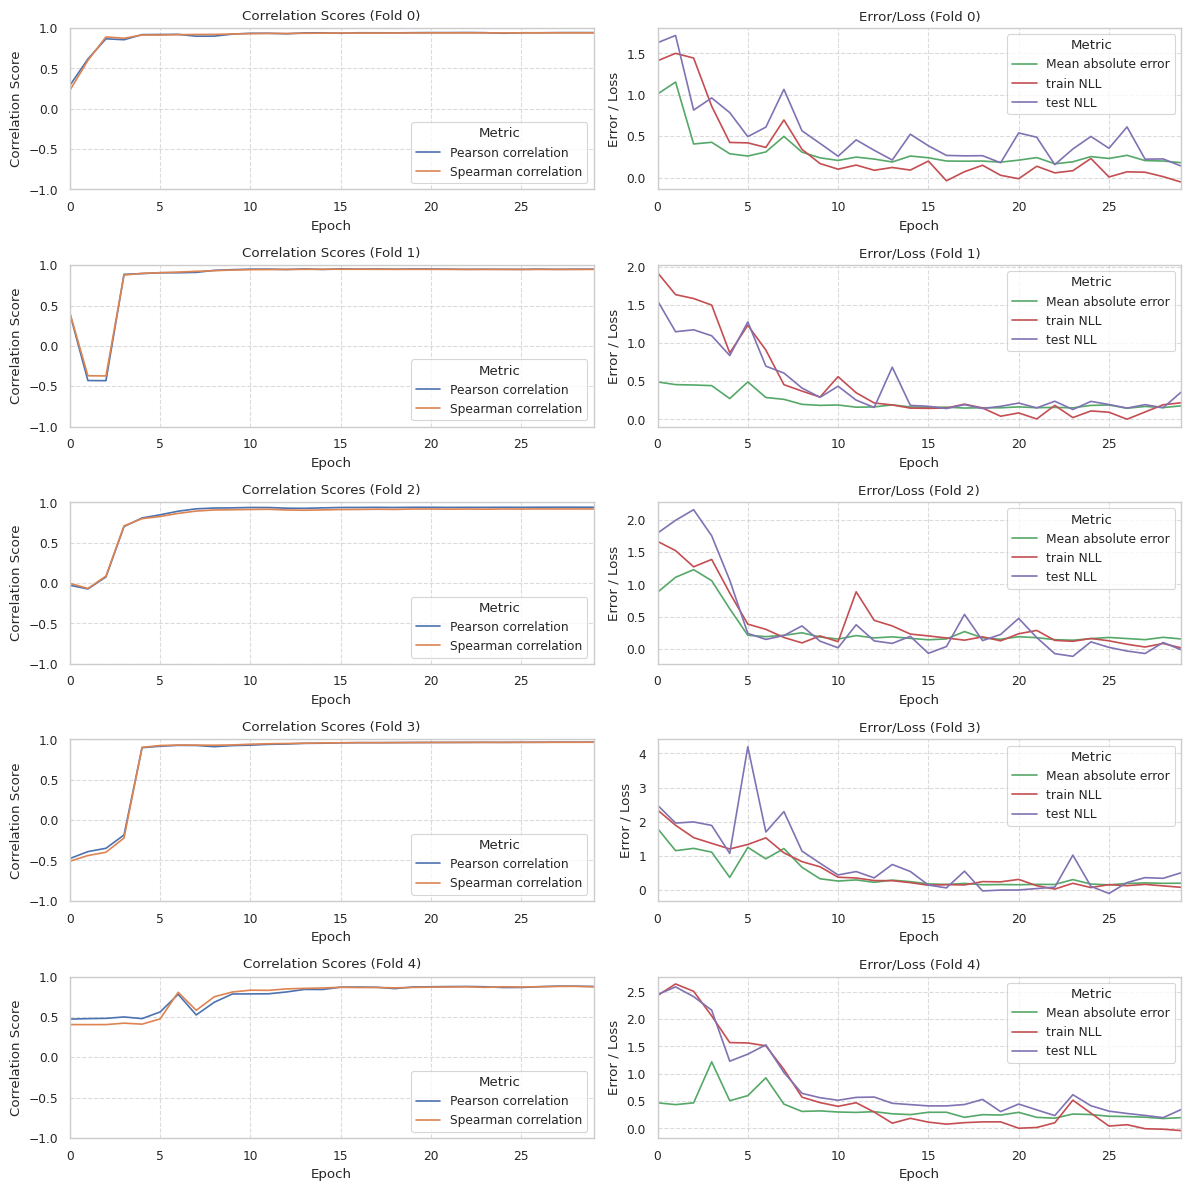

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(context="paper", style="whitegrid")

folds = sorted(stats['Fold'].unique())
n_folds = len(folds)

fig, axes = plt.subplots(nrows=n_folds, ncols=2, figsize=(12, 12), sharex=False)

for i, fold in enumerate(folds):
    fold_stats = stats[stats['Fold'] == fold]

    palette = sns.color_palette()

    # Plot correlations
    ax = axes[i, 0]

    # Convert to long format
    fold_stats_long = fold_stats.melt(
        id_vars='Epoch',
        value_vars=['Pearson correlation', 'Spearman correlation'],
        var_name='Metric',
        value_name='Correlation'
    )

    sns.lineplot(
        data=fold_stats_long,
        x='Epoch',
        y='Correlation',
        hue='Metric',
        palette={'Pearson correlation': palette[0], 'Spearman correlation': palette[1]},
        ax=ax
    )

    ax.set_title(f'Correlation Scores (Fold {fold})')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Correlation Score')
    ax.set_ylim(-1, 1)
    ax.set_xlim(0, stats['Epoch'].max())
    ax.grid(True, linestyle='--', alpha=0.7)
    ax.legend(title='Metric', loc='lower right')

    # Plot errors
    ax = axes[i, 1]

    # Convert to long format
    fold_stats_long = fold_stats.melt(
        id_vars='Epoch',
        value_vars=['Mean absolute error', 'train NLL', 'test NLL'],
        var_name='Error / Loss',
        value_name='Value'
    )

    sns.lineplot(
        data=fold_stats_long,
        x='Epoch',
        y='Value',
        hue='Error / Loss',
        palette={'Mean absolute error': palette[2], 'train NLL': palette[3], 'test NLL': palette[4]},
        ax=ax
    )

    ax.set_title(f'Error/Loss (Fold {fold})')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Error / Loss')
    # ax.set_ylim(0.98, 0.99)
    ax.set_xlim(0, stats['Epoch'].max())
    ax.grid(True, linestyle='--', alpha=0.7)
    ax.legend(title='Metric', loc='upper right')

plt.tight_layout()
plt.show()


In [20]:
notify.send(f'Training complete, results at {OUTPUT_DIR}')